# Data Profiling: Sarasota Wind Data

`SarasotaWindData.csv` — SECOORA ERDDAP gridded wind data (u-component of wind) over the Sarasota-area waters.

**Goal:** Apply the same profiling approach used for `florida_cyanotoxins` and `habsos_cellcounts` (row counts, column types, missing values, duplicates, invalid values, outliers) to this dataset, since it'll also need to be data-quality checked before it can be merged into the modeling dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "../data"
WIND_PATH = f"{DATA_DIR}/SarasotaWindData.csv"

# ERDDAP export: row 0 is the header, row 1 is a units row, data starts at row 2.
UNITS_ROW = [1]

In [2]:
def profile_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a per-column profile: dtype, inferred kind, missingness, uniqueness."""
    n_rows = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        n_missing = s.isna().sum()
        n_unique = s.nunique(dropna=True)
        if pd.api.types.is_numeric_dtype(s):
            kind = "numeric"
        elif pd.api.types.is_bool_dtype(s):
            kind = "boolean"
        else:
            kind = "categorical/text"
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "kind": kind,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n_rows, 2) if n_rows else 0,
            "n_unique": n_unique,
            "sample_values": list(s.dropna().unique()[:3]),
        })
    profile = pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
    print(f"[{name}] shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"[{name}] exact duplicate rows: {df.duplicated().sum():,}")
    return profile


def lon_360_to_180(lon: pd.Series) -> pd.Series:
    """ERDDAP grids often use 0-360 longitude convention; convert to standard -180..180."""
    return ((lon + 180) % 360) - 180

## 1. Load and high-level overview

In [3]:
wind = pd.read_csv(WIND_PATH, skiprows=UNITS_ROW, low_memory=False)
wind.head()

,time,latitude,longitude,uwnd
0,2019-01-01T00:00:00Z,26.625,276.625,-4.081281
1,2019-01-01T00:00:00Z,26.625,276.875,-3.825571
2,2019-01-01T00:00:00Z,26.625,277.125,-3.380656
3,2019-01-01T00:00:00Z,26.625,277.375,-2.561112
4,2019-01-01T00:00:00Z,26.625,277.625,-1.520360


In [4]:
wind_profile = profile_dataset(wind, "SarasotaWindData")
wind_profile

[SarasotaWindData] shape: 549,780 rows x 4 columns
[SarasotaWindData] exact duplicate rows: 0


,column,dtype,kind,n_missing,pct_missing,n_unique,sample_values
0,time,str,categorical/text,0,0.0,11220,"[2019-01-01T00:00:00Z, 2019-01-01T06:00:00Z, 2..."
1,latitude,float64,numeric,0,0.0,7,"[26.625, 26.875, 27.125]"
2,longitude,float64,numeric,0,0.0,7,"[276.625, 276.875, 277.125]"
3,uwnd,float64,numeric,0,0.0,547646,"[-4.0812807, -3.8255713, -3.3806562]"


## 2. Numeric vs. categorical columns

Only 4 columns: `time` (timestamp, treated as categorical/text until parsed), `latitude`, `longitude`, and `uwnd` (the u-component/east-west component of wind speed, in m/s). Note there is **no `vwnd`** (north-south component) in this export — only the east-west wind component is available, so wind *speed* and *direction* can't be fully reconstructed from this file alone.

In [5]:
wind_numeric_cols = wind_profile.loc[wind_profile["kind"] == "numeric", "column"].tolist()
wind_categorical_cols = wind_profile.loc[wind_profile["kind"] != "numeric", "column"].tolist()
print(f"Numeric columns ({len(wind_numeric_cols)}): {wind_numeric_cols}")
print(f"Categorical/text columns ({len(wind_categorical_cols)}): {wind_categorical_cols}")

Numeric columns (3): ['latitude', 'longitude', 'uwnd']
Categorical/text columns (1): ['time']


## 3. Missing values & duplicates

This is a dense reanalysis-model grid (not sparse in-situ sampling), so we expect zero missing values across the full grid x time cross-product.

In [6]:
print("Missing values:\n", wind.isna().sum())
print("\nExact duplicate rows:", wind.duplicated().sum())

n_grid_points = wind[["latitude", "longitude"]].drop_duplicates().shape[0]
n_timestamps = wind["time"].nunique()
print(f"\nUnique (lat, lon) grid points: {n_grid_points}")
print(f"Unique timestamps: {n_timestamps}")
print(f"grid_points x timestamps = {n_grid_points * n_timestamps:,} vs. actual rows = {len(wind):,}")

Missing values:
 time         0
latitude     0
longitude    0
uwnd         0
dtype: int64



Exact duplicate rows: 0

Unique (lat, lon) grid points: 49
Unique timestamps: 11220
grid_points x timestamps = 549,780 vs. actual rows = 549,780


## 4. Invalid values

Checks: date parsing/range, longitude convention (ERDDAP often reports 0-360 instead of -180..180), and physically implausible wind speeds.

In [7]:
wind["time_parsed"] = pd.to_datetime(wind["time"], errors="coerce")
print("Parsed date range:", wind["time_parsed"].min(), "to", wind["time_parsed"].max())
print("Rows where date failed to parse:", wind["time_parsed"].isna().sum())

print("\nRaw latitude range:", wind["latitude"].min(), "to", wind["latitude"].max())
print("Raw longitude range:", wind["longitude"].min(), "to", wind["longitude"].max())
print("-> longitude uses the 0-360 convention (Sarasota, FL is ~-82.5, i.e. 277.5 in 0-360 form)")

wind["longitude_180"] = lon_360_to_180(wind["longitude"])
print("Converted longitude range:", wind["longitude_180"].min(), "to", wind["longitude_180"].max())

Parsed date range: 2019-01-01 00:00:00+00:00 to 2026-09-15 18:00:00+00:00
Rows where date failed to parse: 0

Raw latitude range: 26.625 to 28.125
Raw longitude range: 276.625 to 278.125
-> longitude uses the 0-360 convention (Sarasota, FL is ~-82.5, i.e. 277.5 in 0-360 form)
Converted longitude range: -83.375 to -81.875


In [8]:
print("uwnd (u-component of wind, m/s) stats:\n", wind["uwnd"].describe())

# Sustained wind speeds above ~50 m/s (~180 km/h, category 5 hurricane force) would be extreme for this component alone.
extreme_wind = wind[wind["uwnd"].abs() > 50]
print("\nRows with |uwnd| > 50 m/s (physically implausible for a single component):", len(extreme_wind))

uwnd (u-component of wind, m/s) stats:
 count    549780.000000
mean         -0.874189
std           3.537986
min         -23.263628
25%          -3.157215
50%          -0.879896
75%           1.593204
max          35.974590
Name: uwnd, dtype: float64

Rows with |uwnd| > 50 m/s (physically implausible for a single component): 0


## 5. Outliers

IQR bounds: [-10.28, 8.72] m/s
Rows outside IQR bounds: 4973 (0.90%)


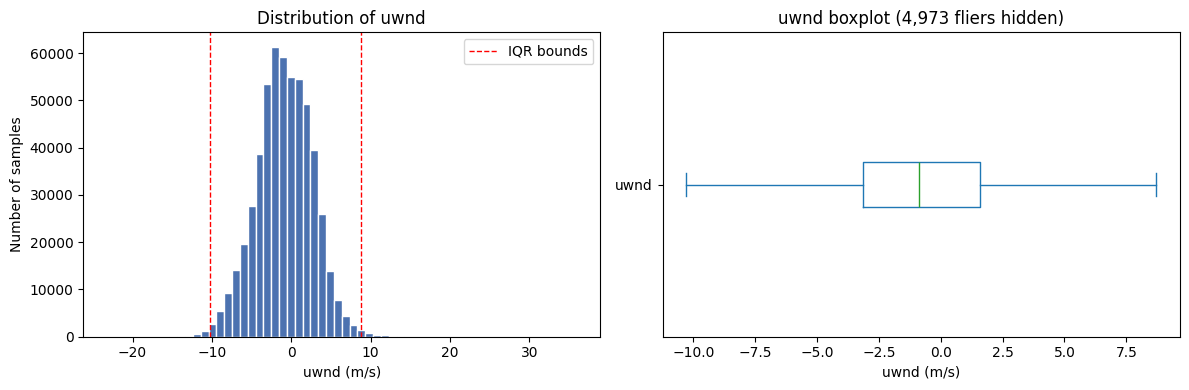

In [9]:
q1, q3 = wind["uwnd"].quantile(0.25), wind["uwnd"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_outliers = int(((wind["uwnd"] < lower) | (wind["uwnd"] > upper)).sum())
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}] m/s")
print(f"Rows outside IQR bounds: {n_outliers} ({100 * n_outliers / len(wind):.2f}%)")

# Fliers are hidden (showfliers=False): with this many points beyond the IQR bound, plotting each
# as a marker overplots into a solid smear rather than a readable boxplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(wind["uwnd"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(lower, color="red", linestyle="--", linewidth=1, label="IQR bounds")
axes[0].axvline(upper, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("uwnd (m/s)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Distribution of uwnd")
axes[0].legend()

wind["uwnd"].plot(kind="box", vert=False, ax=axes[1], showfliers=False)
axes[1].set_xlabel("uwnd (m/s)")
axes[1].set_title(f"uwnd boxplot ({n_outliers:,} fliers hidden)")
plt.tight_layout()
plt.show()